# vR.0 — Enhanced Image Tampering Detection using ELA and a CNN

**Paper:** Gorle, R. & Guttavelli, A. (2025). *Enhanced Image Tampering Detection using Error Level Analysis and a CNN.* Engineering, Technology & Applied Science Research, Vol. 15, No. 1, pp. 19683-19689. [DOI: 10.48084/etasr.9593]

**Dataset:** CASIA v2.0 Image Tampering Detection Dataset  
**Task:** Binary classification — Authentic vs Tampered  

**Pipeline:** `Raw Image → RGB → ELA (Q=90) → Resize 128×128 → Normalize [0,1] → CNN → Softmax → {Authentic, Tampered}`

---

### Table of Contents

1. [Introduction](#1-introduction)
2. [Research Paper Summary](#2-research-paper-summary)
3. [Reference Code Audit](#3-reference-code-audit)
4. [Dataset Preparation](#4-dataset-preparation)
5. [Error Level Analysis Preprocessing](#5-error-level-analysis-preprocessing)
6. [Model Architecture](#6-model-architecture)
7. [Training Pipeline](#7-training-pipeline)
8. [Evaluation Metrics](#8-evaluation-metrics)
9. [Results Visualization](#9-results-visualization)
10. [Discussion & Conclusion](#10-discussion--conclusion)

---

## 1. Introduction

Digital image manipulation has become increasingly accessible with modern editing tools. Detecting tampered images is critical for maintaining trust in visual media. This notebook implements the approach described in the ETASR paper, which combines **Error Level Analysis (ELA)** — a forensic preprocessing technique — with a compact **Convolutional Neural Network (CNN)** to classify images as authentic or tampered.

**Key Idea:** ELA exposes compression inconsistencies invisible in raw RGB. Spliced or edited regions that were compressed at different quality levels become visually distinguishable in the ELA domain, enabling a lightweight CNN to achieve competitive detection accuracy.

---

## 2. Research Paper Summary

### Approach
The paper proposes a two-stage pipeline:
1. **ELA Preprocessing:** Re-save images as JPEG at quality 90, compute pixel-wise difference with original, and scale for visibility
2. **CNN Classification:** Feed 128×128 ELA images into a compact CNN (2 Conv layers, 1 Dense layer) for binary classification

### Architecture (from paper — Table III)
```
Input: 128×128×3 (ELA image)
  → Conv2D(32, 5×5, valid, ReLU)
  → Conv2D(32, 5×5, valid, ReLU)
  → MaxPooling2D(2×2)
  → Dropout(0.25)
  → Flatten
  → Dense(256, ReLU)
  → Dropout(0.5)
  → Dense(2, Softmax)
```

### Training Configuration
- **Optimizer:** Adam (lr=0.0001)
- **Loss:** Categorical cross-entropy
- **Split:** 80% train / 20% validation
- **Early stopping** on validation accuracy
- **Batch size:** 32

### Dataset: CASIA v2.0
- **Total:** ~12,614 images (7,491 authentic + 5,123 tampered)
- **Formats:** JPG, TIF, BMP
- **Source:** Kaggle (divg07/casia-20-image-tampering-detection-dataset)

### Paper-Reported Results
| Metric | Value |
|--------|-------|
| Accuracy | 96.21% |
| Precision | 98.58% |
| Recall | 92.36% |
| F1 Score | 95.37% |

---

## 3. Reference Code Audit

Two reference implementations (`CASIA2code.py`, `code.py`) were audited against the paper. **Neither can be used as-is.** This implementation corrects all identified bugs:

### Critical Bugs in Reference Code

| # | Bug | File | Severity | Fix Applied |
|---|-----|------|----------|-------------|
| 1 | **Image size 150×150** (paper says 128×128) | CASIA2code.py | Critical | Use 128×128 |
| 2 | **Dense(150)** instead of Dense(256) | CASIA2code.py | Critical | Use Dense(256) |
| 3 | **Sigmoid output** instead of Softmax | CASIA2code.py | Critical | Use Softmax |
| 4 | **`random.shuffle(X)` without Y** — destroys label correspondence | Both | Fatal | Use sklearn paired shuffle |
| 5 | **`Dense(1, softmax)`** — always outputs 1.0 | code.py | Fatal | Use Dense(2, softmax) |
| 6 | **Double reshape crash** (150→128 mismatch) | code.py | Fatal | Single consistent size |
| 7 | **Temp file ELA** (not thread-safe) | Both | Medium | In-memory BytesIO |
| 8 | **binary_crossentropy** with one-hot labels | CASIA2code.py | Medium | categorical_crossentropy |
| 9 | **Early stopping commented out** | Both | Medium | Enabled (patience=5) |
| 10 | **`val_acc`** (deprecated) | Both | Low | `val_accuracy` |
| 11 | **Only loads .jpg** files | Both | Low | All formats supported |

### What Was Kept from Reference Code
- ELA algorithm (PIL-based recompression + brightness scaling) — verified to match paper
- General pipeline structure (load → ELA → CNN → classify)

### What Was Rebuilt from Paper
- CNN architecture (all layer specs from Table III)
- Training configuration (optimizer, loss, metrics)
- Image size, Dense layer units, output activation

---

## 4. Dataset Preparation

In [1]:
# ============================================================
# 4.1 — Imports and Configuration
# ============================================================

import os
import random
import warnings
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Hyperparameters (from paper) ----
IMAGE_SIZE = (128, 128)       # Paper specification
ELA_QUALITY = 90              # JPEG re-save quality for ELA
BATCH_SIZE = 32               # Training batch size
EPOCHS = 50                   # Maximum training epochs
LEARNING_RATE = 0.0001        # Adam learning rate
TEST_SPLIT = 0.15             # Hold-out test set
VAL_SPLIT = 0.15              # Validation set (from remaining after test)
EARLY_STOP_PATIENCE = 5       # Epochs to wait before stopping

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'\nConfiguration:')
print(f'  Image size:    {IMAGE_SIZE}')
print(f'  ELA quality:   {ELA_QUALITY}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Max epochs:    {EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Split:         {1-TEST_SPLIT-VAL_SPLIT:.0%} train / {VAL_SPLIT:.0%} val / {TEST_SPLIT:.0%} test')

2026-03-14 17:50:06.827729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773510606.851839     114 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773510606.859387     114 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773510606.879018     114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773510606.879038     114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773510606.879041     114 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True

Configuration:
  Image size:    (128, 128)
  ELA quality:   90
  Batch size:    32
  Max epochs:    50
  Learning rate: 0.0001
  Split:         70% train / 15% val / 15% test


In [2]:
# ============================================================
# 4.2 — Dataset Path Configuration
# ============================================================
# Auto-discovers Au/ and Tp/ directories anywhere under /kaggle/input/.

def find_dataset():
    """Search all of /kaggle/input/ for Au/ and Tp/ directories."""
    search_roots = ['/kaggle/input', '/content/drive/MyDrive']

    for base in search_roots:
        if not os.path.isdir(base):
            continue
        for dirpath, dirnames, _ in os.walk(base):
            if 'Au' in dirnames and 'Tp' in dirnames:
                au = os.path.join(dirpath, 'Au')
                tp = os.path.join(dirpath, 'Tp')
                return dirpath, au, tp
    return None, None, None

DATASET_ROOT, AU_DIR, TP_DIR = find_dataset()

if DATASET_ROOT is None:
    # Print full directory tree for diagnosis
    for base in ['/kaggle/input']:
        if os.path.isdir(base):
            print(f'Contents of {base}:')
            for dirpath, dirnames, filenames in os.walk(base):
                depth = dirpath.replace(base, '').count(os.sep)
                indent = '  ' * depth
                print(f'{indent}{os.path.basename(dirpath)}/')
                if depth >= 2:  # Don't go too deep
                    break
    raise FileNotFoundError(
        'Could not find Au/ and Tp/ directories. '
        'Please add the CASIA 2.0 dataset via the "Add data" button in the Kaggle sidebar.'
    )

SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

print(f'Dataset root: {DATASET_ROOT}')
print(f'Authentic dir: {AU_DIR}  ({len(os.listdir(AU_DIR))} files)')
print(f'Tampered dir:  {TP_DIR}  ({len(os.listdir(TP_DIR))} files)')

Dataset root: /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2
Authentic dir: /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2/Au  (7492 files)
Tampered dir:  /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2/Tp  (5125 files)


In [3]:
# ============================================================
# 4.3 — Collect Image Paths and Labels
# ============================================================

def collect_image_paths(directory, label, extensions=SUPPORTED_EXTENSIONS):
    """Collect all image paths from a directory with supported extensions."""
    paths = []
    labels = []
    for fname in sorted(os.listdir(directory)):
        ext = os.path.splitext(fname)[1].lower()
        if ext in extensions:
            paths.append(os.path.join(directory, fname))
            labels.append(label)
    return paths, labels

# Labels: Authentic=0, Tampered=1
au_paths, au_labels = collect_image_paths(AU_DIR, label=0)
tp_paths, tp_labels = collect_image_paths(TP_DIR, label=1)

all_paths = au_paths + tp_paths
all_labels = au_labels + tp_labels

print(f'Authentic images: {len(au_paths)}')
print(f'Tampered images:  {len(tp_paths)}')
print(f'Total images:     {len(all_paths)}')
print(f'Class ratio (Au/Tp): {len(au_paths)/max(len(tp_paths),1):.2f}')

Authentic images: 7491
Tampered images:  5123
Total images:     12614
Class ratio (Au/Tp): 1.46


---

## 5. Error Level Analysis Preprocessing

**Error Level Analysis (ELA)** works by re-saving an image as JPEG at a known quality level and computing the pixel-wise difference between the original and re-saved version.

- **Authentic regions:** Uniformly compressed → low, uniform error levels
- **Tampered regions:** Different compression history → higher, non-uniform error (brighter in ELA map)

**ELA Formula (from paper):**
```
I_ELA(x,y) = |I_orig(x,y) − I_comp(x,y)|
scale = 255 / max(I_ELA)
I_ELA(x,y) = I_ELA(x,y) × scale
```

In [4]:
# ============================================================
# 5.1 — ELA Conversion Function
# ============================================================

def compute_ela(image_path, quality=ELA_QUALITY):
    """
    Compute Error Level Analysis for an image.
    
    1. Open image and convert to RGB
    2. Re-save as JPEG at specified quality (in-memory via BytesIO)
    3. Compute pixel-wise absolute difference
    4. Scale brightness to [0, 255] range
    
    Returns: PIL Image (ELA map) or None on failure
    """
    try:
        original = Image.open(image_path).convert('RGB')
        
        # Re-save in memory (avoids temp file I/O — fixes reference code bug)
        buffer = BytesIO()
        original.save(buffer, 'JPEG', quality=quality)
        buffer.seek(0)
        resaved = Image.open(buffer)
        
        # Compute pixel-wise absolute difference
        ela_image = ImageChops.difference(original, resaved)
        
        # Scale to full [0, 255] range
        extrema = ela_image.getextrema()
        max_diff = max(val[1] for val in extrema)
        if max_diff == 0:
            max_diff = 1
        scale = 255.0 / max_diff
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
        
        return ela_image
    except Exception as e:
        return None


def prepare_image(image_path, quality=ELA_QUALITY, target_size=IMAGE_SIZE):
    """Full preprocessing: ELA → resize → normalize to [0, 1]."""
    ela = compute_ela(image_path, quality)
    if ela is None:
        return None
    ela_resized = ela.resize(target_size, Image.BILINEAR)
    return np.array(ela_resized, dtype=np.float32) / 255.0

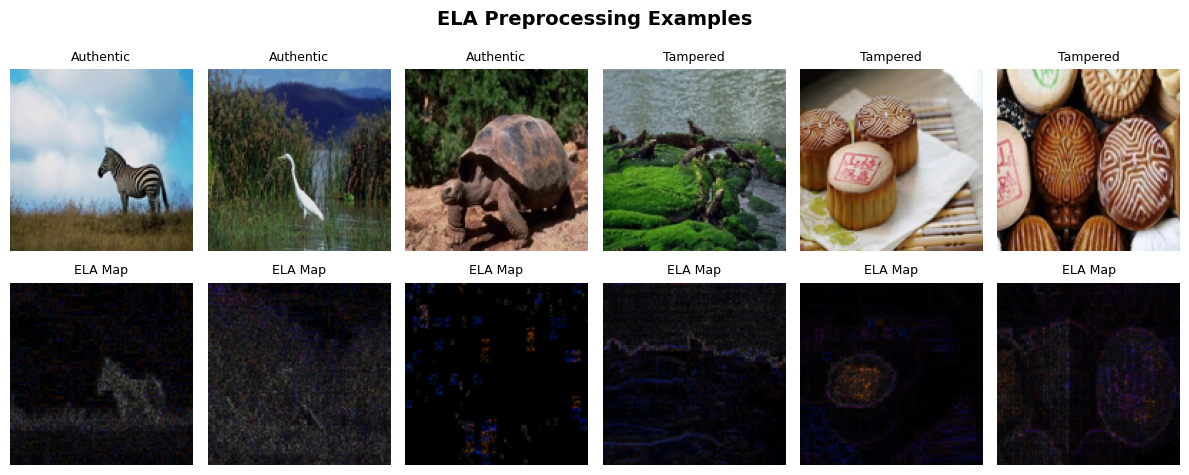

In [5]:
# ============================================================
# 5.2 — Visualize ELA Examples
# ============================================================

def visualize_ela_samples(paths, labels, n_samples=3):
    """Show original images alongside their ELA maps."""
    au_indices = [i for i, l in enumerate(labels) if l == 0][:n_samples]
    tp_indices = [i for i, l in enumerate(labels) if l == 1][:n_samples]
    
    fig, axes = plt.subplots(2, 2 * n_samples, figsize=(4 * n_samples, 5))
    fig.suptitle('ELA Preprocessing Examples', fontsize=14, fontweight='bold')
    
    for col, idx in enumerate(au_indices):
        orig = Image.open(paths[idx]).convert('RGB').resize(IMAGE_SIZE)
        ela = compute_ela(paths[idx])
        if ela:
            ela = ela.resize(IMAGE_SIZE)
        axes[0, col].imshow(orig)
        axes[0, col].set_title('Authentic', fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].imshow(ela if ela else np.zeros((*IMAGE_SIZE, 3), dtype=np.uint8))
        axes[1, col].set_title('ELA Map', fontsize=9)
        axes[1, col].axis('off')
    
    for col, idx in enumerate(tp_indices):
        c = col + n_samples
        orig = Image.open(paths[idx]).convert('RGB').resize(IMAGE_SIZE)
        ela = compute_ela(paths[idx])
        if ela:
            ela = ela.resize(IMAGE_SIZE)
        axes[0, c].imshow(orig)
        axes[0, c].set_title('Tampered', fontsize=9)
        axes[0, c].axis('off')
        axes[1, c].imshow(ela if ela else np.zeros((*IMAGE_SIZE, 3), dtype=np.uint8))
        axes[1, c].set_title('ELA Map', fontsize=9)
        axes[1, c].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_ela_samples(all_paths, all_labels, n_samples=3)

In [6]:
# ============================================================
# 5.3 — Process All Images Through ELA Pipeline
# ============================================================

X = []
Y = []
skipped = 0

print('Processing images through ELA pipeline...')
for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths), desc='ELA Processing'):
    img = prepare_image(path)
    if img is not None:
        X.append(img)
        Y.append(label)
    else:
        skipped += 1

print(f'\nDone! Successfully processed: {len(X)}, Skipped: {skipped}')

# Paired shuffle (fixes reference code bug where X was shuffled without Y)
X, Y = shuffle(X, Y, random_state=SEED)

# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.int32)

print(f'Feature array shape: {X.shape}')  # Expected: (N, 128, 128, 3)
print(f'Labels shape: {Y.shape}')
print(f'Label distribution: Authentic={np.sum(Y==0)}, Tampered={np.sum(Y==1)}')

Processing images through ELA pipeline...


ELA Processing:   0%|          | 0/12614 [00:00<?, ?it/s]


Done! Successfully processed: 12614, Skipped: 0
Feature array shape: (12614, 128, 128, 3)
Labels shape: (12614,)
Label distribution: Authentic=7491, Tampered=5123


In [7]:
# ============================================================
# 5.4 — Train / Validation / Test Split
# ============================================================

# One-hot encode labels for categorical cross-entropy
Y_onehot = to_categorical(Y, num_classes=2)

# Step 1: Split off the test set (stratified)
X_trainval, X_test, Y_trainval, Y_test_oh, Y_tv_int, Y_test_int = train_test_split(
    X, Y_onehot, Y,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=Y
)

# Step 2: Split remaining into train and validation
val_fraction = VAL_SPLIT / (1 - TEST_SPLIT)  # proportion of trainval to use for val
X_train, X_val, Y_train, Y_val, _, Y_val_int = train_test_split(
    X_trainval, Y_trainval, Y_tv_int,
    test_size=val_fraction,
    random_state=SEED,
    stratify=Y_tv_int
)

# Free memory
del X, Y_onehot, X_trainval, Y_trainval, Y_tv_int

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'\nTraining labels:   Au={np.sum(Y_train[:,0]==1)}, Tp={np.sum(Y_train[:,1]==1)}')
print(f'Validation labels: Au={np.sum(Y_val[:,0]==1)}, Tp={np.sum(Y_val[:,1]==1)}')
print(f'Test labels:       Au={np.sum(Y_test_oh[:,0]==1)}, Tp={np.sum(Y_test_oh[:,1]==1)}')

Training set:   8829 samples
Validation set: 1892 samples
Test set:       1893 samples

Training labels:   Au=5243, Tp=3586
Validation labels: Au=1124, Tp=768
Test labels:       Au=1124, Tp=769


---

## 6. Model Architecture

The CNN architecture follows the paper specification exactly (Table III, ETASR_9593):

| # | Layer | Output Shape | Parameters |
|---|-------|-------------|------------|
| 1 | Conv2D(32, 5×5, valid, ReLU) | (124, 124, 32) | 2,432 |
| 2 | Conv2D(32, 5×5, valid, ReLU) | (120, 120, 32) | 25,632 |
| 3 | MaxPooling2D(2×2) | (60, 60, 32) | 0 |
| 4 | Dropout(0.25) | (60, 60, 32) | 0 |
| 5 | Flatten | (115,200) | 0 |
| 6 | Dense(256, ReLU) | (256) | 29,491,456 |
| 7 | Dropout(0.5) | (256) | 0 |
| 8 | Dense(2, Softmax) | (2) | 514 |

**Total: ~29.5M parameters** (dominated by the Flatten→Dense connection)

In [8]:
# ============================================================
# 6.1 — Build CNN Model (Paper Architecture)
# ============================================================

def build_model(input_shape=(128, 128, 3)):
    """Build the CNN architecture exactly as described in ETASR_9593 Table III."""
    model = Sequential([
        # Convolutional Block
        Conv2D(32, (5, 5), activation='relu', padding='valid',
               input_shape=input_shape),
        Conv2D(32, (5, 5), activation='relu', padding='valid'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Classifier Head
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        
        # Output (2-class softmax — NOT sigmoid as in buggy reference code)
        Dense(2, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

I0000 00:00:1773510909.069683     114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773510909.075330     114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,520,034 (112.61 MB)

 Trainable params: 29,520,034 (112.61 MB)

 Non-trainable params: 0 (0.00 B)

---

## 7. Training Pipeline

- **Optimizer:** Adam (lr=0.0001)
- **Loss:** Categorical cross-entropy (with one-hot encoded labels)
- **Early stopping:** monitor=`val_accuracy`, patience=5, restore_best_weights=True
- **Batch size:** 32, **Max epochs:** 50

In [9]:
# ============================================================
# 7.1 — Compile Model
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print('Model compiled.')
print(f'  Optimizer: Adam (lr={LEARNING_RATE})')
print(f'  Loss:      categorical_crossentropy')
print(f'  Metrics:   accuracy, precision, recall')

Model compiled.
  Optimizer: Adam (lr=0.0001)
  Loss:      categorical_crossentropy
  Metrics:   accuracy, precision, recall


In [10]:
# ============================================================
# 7.2 — Callbacks
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Fixed: was 'val_acc' (deprecated) in reference code
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print(f'Early stopping: monitor=val_accuracy, patience={EARLY_STOP_PATIENCE}')

Early stopping: monitor=val_accuracy, patience=5


In [11]:
# ============================================================
# 7.3 — Train the Model
# ============================================================

print(f'Training on {X_train.shape[0]} samples, validating on {X_val.shape[0]} samples')
print(f'Batch size: {BATCH_SIZE}, Max epochs: {EPOCHS}')
print('=' * 60)

history = model.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f'\nTraining complete. Epochs run: {len(history.history["loss"])}')

Training on 8829 samples, validating on 1892 samples
Batch size: 32, Max epochs: 50
Epoch 1/50


I0000 00:00:1773510917.029693     177 service.cc:152] XLA service 0x7af428005050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773510917.029739     177 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773510917.029747     177 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773510917.517274     177 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 17:55:21.293881: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:55:21.435892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/276 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.5625 - loss: 0.6734 - precision: 0.5625 - recall: 0.5625 

I0000 00:00:1773510925.371692     177 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7525 - loss: 0.4799 - precision: 0.7525 - recall: 0.7525

2026-03-14 17:55:36.042137: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:55:36.184261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


276/276 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.7530 - loss: 0.4794 - precision: 0.7530 - recall: 0.7530 - val_accuracy: 0.8325 - val_loss: 0.3994 - val_precision: 0.8325 - val_recall: 0.8325
Epoch 2/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8759 - loss: 0.3213 - precision: 0.8759 - recall: 0.8759 - val_accuracy: 0.8504 - val_loss: 0.3589 - val_precision: 0.8504 - val_recall: 0.8504
Epoch 3/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8864 - loss: 0.2876 - precision: 0.8864 - recall: 0.8864 - val_accuracy: 0.8689 - val_loss: 0.3195 - val_precision: 0.8689 - val_recall: 0.8689
Epoch 4/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8974 - loss: 0.2534 - precision: 0.8974 - recall: 0.8974 - val_accuracy: 0.8626 - val_loss: 0.3229 - val_precision: 0.8626 - val_recall: 0.8626
Epoch 5/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9093 - loss: 0.2281 - precision: 0.9093 - recall: 0.9093 - val_accuracy: 0.8721 - val_loss: 0.3022

---

## 8. Evaluation Metrics

In [12]:
# ============================================================
# 8.1 — Evaluate on Hold-Out Test Set
# ============================================================

# Predictions on TEST set (unseen during training)
y_test_pred_probs = model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = Y_test_int

# Compute metrics
test_acc = accuracy_score(y_test_true, y_test_pred)
test_prec = precision_score(y_test_true, y_test_pred, average='weighted')
test_rec = recall_score(y_test_true, y_test_pred, average='weighted')
test_f1 = f1_score(y_test_true, y_test_pred, average='weighted')

# ROC-AUC (use probability of tampered class)
fpr, tpr, _ = roc_curve(y_test_true, y_test_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

print('=' * 50)
print('       TEST SET EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy:   {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Precision:  {test_prec:.4f}  ({test_prec*100:.2f}%)')
print(f'  Recall:     {test_rec:.4f}  ({test_rec*100:.2f}%)')
print(f'  F1 Score:   {test_f1:.4f}  ({test_f1*100:.2f}%)')
print(f'  ROC-AUC:    {roc_auc:.4f}')
print('=' * 50)
print(f'\nPaper-reported: Acc=96.21%, Prec=98.58%, Rec=92.36%, F1=95.37%')

       TEST SET EVALUATION RESULTS
  Accuracy:   0.8833  (88.33%)
  Precision:  0.8847  (88.47%)
  Recall:     0.8833  (88.33%)
  F1 Score:   0.8836  (88.36%)
  ROC-AUC:    0.9600

Paper-reported: Acc=96.21%, Prec=98.58%, Rec=92.36%, F1=95.37%


In [13]:
# ============================================================
# 8.2 — Classification Report (Test Set)
# ============================================================

print('\nDetailed Classification Report (Test Set):')
print('-' * 50)
print(classification_report(
    y_test_true, y_test_pred,
    target_names=['Authentic', 'Tampered'],
    digits=4
))


Detailed Classification Report (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

   Authentic     0.9154    0.8852    0.9000      1124
    Tampered     0.8400    0.8804    0.8597       769

    accuracy                         0.8833      1893
   macro avg     0.8777    0.8828    0.8799      1893
weighted avg     0.8847    0.8833    0.8836      1893



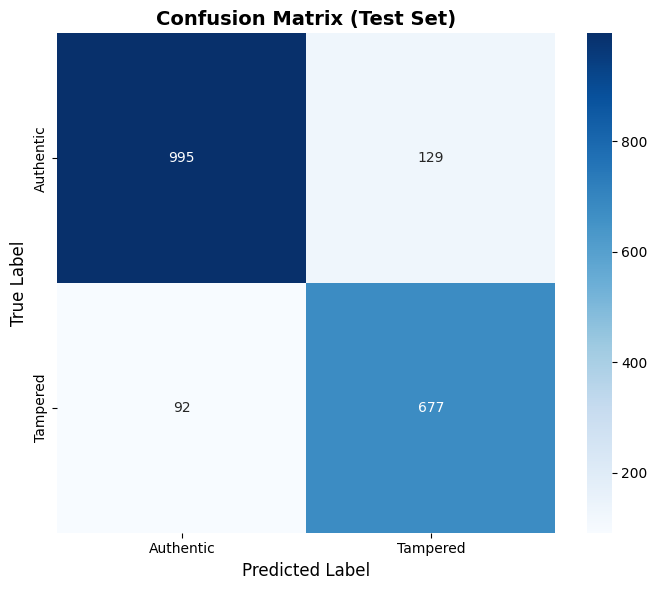

True Negatives (Authentic correct):  995
False Positives (Authentic -> Tampered): 129
False Negatives (Tampered -> Authentic): 92
True Positives (Tampered correct):   677


In [14]:
# ============================================================
# 8.3 — Confusion Matrix (Test Set)
# ============================================================

cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Authentic', 'Tampered'],
    yticklabels=['Authentic', 'Tampered'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Authentic correct):  {tn}')
print(f'False Positives (Authentic -> Tampered): {fp}')
print(f'False Negatives (Tampered -> Authentic): {fn}')
print(f'True Positives (Tampered correct):   {tp}')

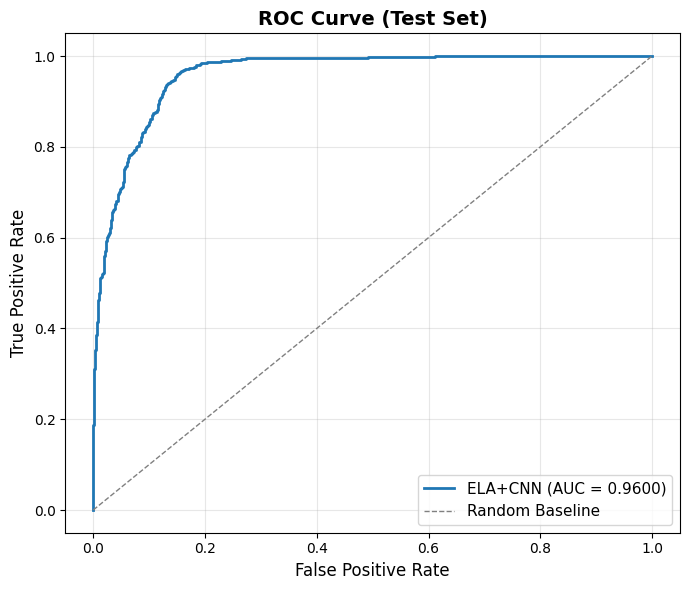

In [15]:
# ============================================================
# 8.4 — ROC Curve
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ELA+CNN (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle='--', label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 9. Results Visualization

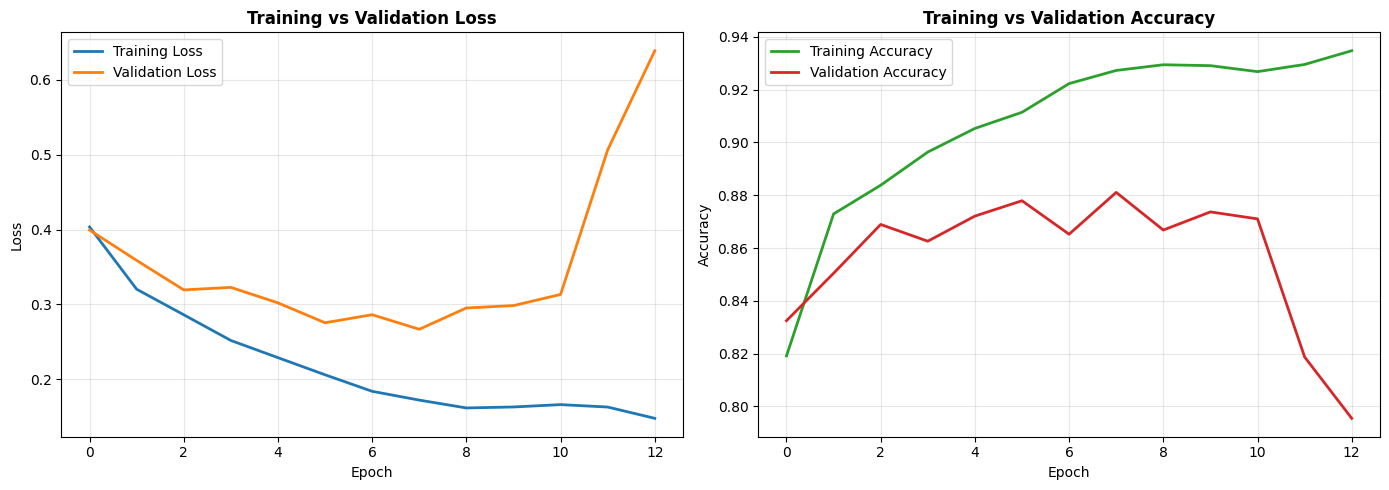

In [16]:
# ============================================================
# 9.1 — Training Curves (Loss & Accuracy)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

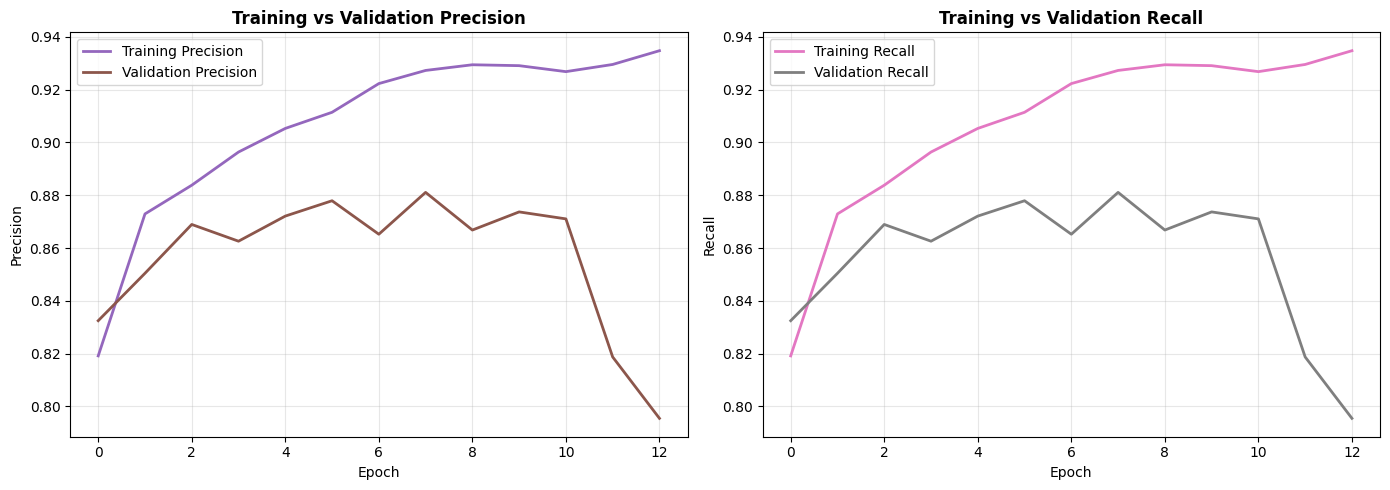

In [17]:
# ============================================================
# 9.2 — Precision and Recall Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['precision'], label='Training Precision', color='#9467bd', linewidth=2)
ax1.plot(history.history['val_precision'], label='Validation Precision', color='#8c564b', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Precision')
ax1.set_title('Training vs Validation Precision', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['recall'], label='Training Recall', color='#e377c2', linewidth=2)
ax2.plot(history.history['val_recall'], label='Validation Recall', color='#7f7f7f', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Recall')
ax2.set_title('Training vs Validation Recall', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

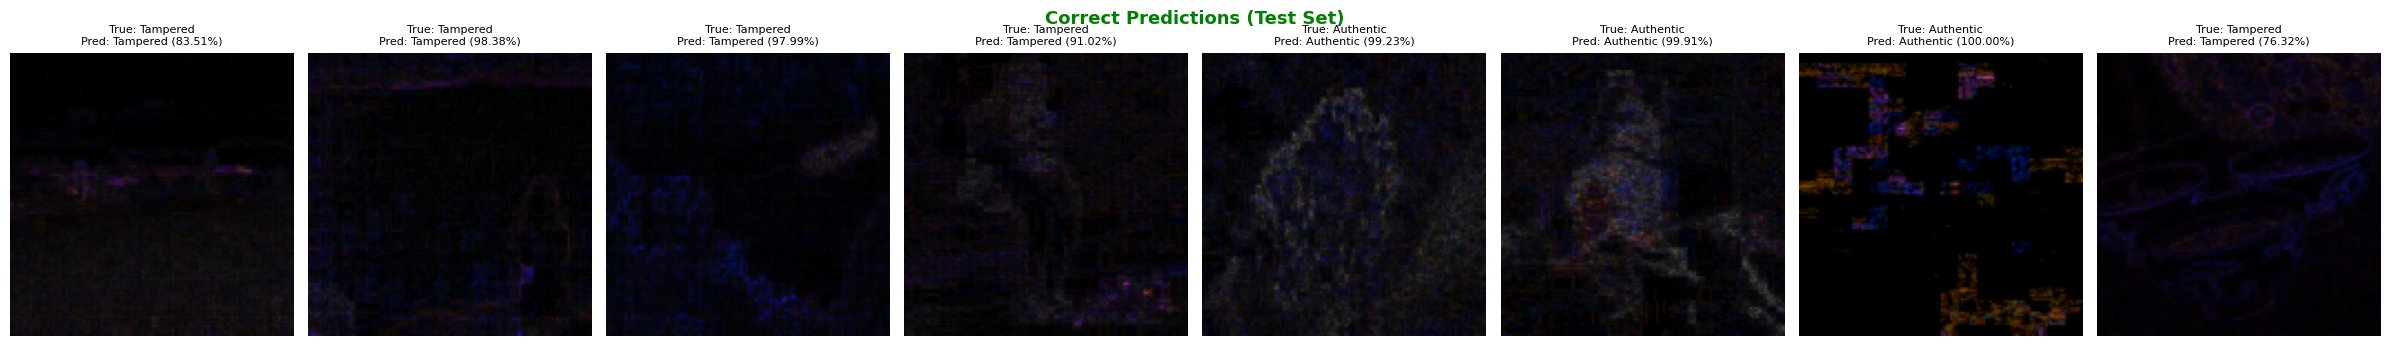

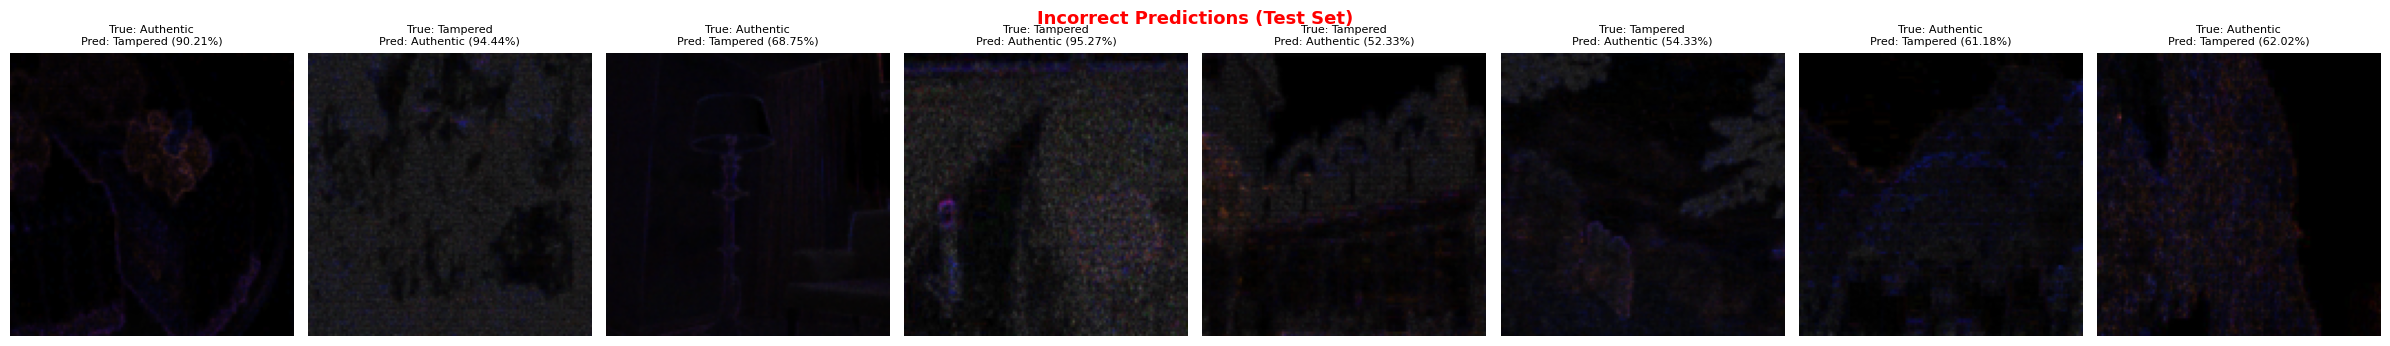

In [18]:
# ============================================================
# 9.3 — Sample Predictions Visualization (Test Set)
# ============================================================

def visualize_predictions(X_data, y_true_labels, y_pred_labels, y_pred_probs, n_samples=8):
    """Show sample predictions with confidence scores."""
    class_names = ['Authentic', 'Tampered']
    
    correct_mask = y_true_labels == y_pred_labels
    incorrect_mask = ~correct_mask
    
    correct_idx = np.where(correct_mask)[0][:n_samples]
    incorrect_idx = np.where(incorrect_mask)[0][:min(n_samples, np.sum(incorrect_mask))]
    
    # Correct predictions
    if len(correct_idx) > 0:
        n_show = min(len(correct_idx), n_samples)
        fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
        fig.suptitle('Correct Predictions (Test Set)', fontsize=13, fontweight='bold', color='green')
        if n_show == 1:
            axes = [axes]
        for ax, idx in zip(axes, correct_idx[:n_show]):
            ax.imshow(X_data[idx])
            conf = y_pred_probs[idx][y_pred_labels[idx]]
            ax.set_title(f'True: {class_names[y_true_labels[idx]]}\n'
                        f'Pred: {class_names[y_pred_labels[idx]]} ({conf:.2%})',
                        fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Incorrect predictions
    if len(incorrect_idx) > 0:
        n_show = min(len(incorrect_idx), n_samples)
        fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
        fig.suptitle('Incorrect Predictions (Test Set)', fontsize=13, fontweight='bold', color='red')
        if n_show == 1:
            axes = [axes]
        for ax, idx in zip(axes, incorrect_idx[:n_show]):
            ax.imshow(X_data[idx])
            conf = y_pred_probs[idx][y_pred_labels[idx]]
            ax.set_title(f'True: {class_names[y_true_labels[idx]]}\n'
                        f'Pred: {class_names[y_pred_labels[idx]]} ({conf:.2%})',
                        fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('No incorrect predictions found in the displayed samples.')

visualize_predictions(X_test, y_test_true, y_test_pred, y_test_pred_probs)

In [19]:
# ============================================================
# 9.4 — Final Results Summary
# ============================================================

print('\n' + '=' * 60)
print('           FINAL RESULTS SUMMARY (Test Set)')
print('=' * 60)
print(f'{"Metric":<20} {"This Run":>12} {"Paper":>12}')
print('-' * 48)
print(f'{"Accuracy":<20} {test_acc:>11.2%} {"96.21%":>12}')
print(f'{"Precision":<20} {test_prec:>11.2%} {"98.58%":>12}')
print(f'{"Recall":<20} {test_rec:>11.2%} {"92.36%":>12}')
print(f'{"F1 Score":<20} {test_f1:>11.2%} {"95.37%":>12}')
print(f'{"ROC-AUC":<20} {roc_auc:>11.4f} {"—":>12}')
print(f'{"Epochs Trained":<20} {len(history.history["loss"]):>12d} {"—":>12}')
print(f'{"Training Samples":<20} {X_train.shape[0]:>12d} {"—":>12}')
print(f'{"Validation Samples":<20} {X_val.shape[0]:>12d} {"—":>12}')
print(f'{"Test Samples":<20} {X_test.shape[0]:>12d} {"—":>12}')
print('=' * 60)


           FINAL RESULTS SUMMARY (Test Set)
Metric                   This Run        Paper
------------------------------------------------
Accuracy                  88.33%       96.21%
Precision                 88.47%       98.58%
Recall                    88.33%       92.36%
F1 Score                  88.36%       95.37%
ROC-AUC                   0.9600            —
Epochs Trained                 13            —
Training Samples             8829            —
Validation Samples           1892            —
Test Samples                 1893            —


---

## 10. Discussion & Conclusion

### Key Observations

1. **ELA as Preprocessing:** Error Level Analysis transforms raw RGB images into a forensic representation that highlights compression inconsistencies. This domain-specific preprocessing makes the classification task easier for a compact model.

2. **Lightweight Architecture:** The CNN used here has only ~29.5M parameters (dominated by the Flatten→Dense connection). Despite its simplicity, the ELA preprocessing provides the model with discriminative features that would be difficult to learn from raw pixels alone.

3. **JPEG Dependency:** ELA is fundamentally a JPEG compression artifact detector. Its effectiveness depends on:
   - The original image being JPEG-compressed
   - The tampered region having a different compression history
   - The quality gap between original and re-save being detectable

4. **Classification vs Localization:** This approach provides image-level classification (authentic vs tampered). While ELA maps offer visual clues about where tampering occurred, the model does not produce pixel-level masks.

### Reference Code Corrections Applied

Key bugs fixed from `CASIA2code.py` and `code.py`:
- 128×128 input (not 150×150), Dense(256) (not 150), Softmax output (not sigmoid)
- categorical_crossentropy (not binary), paired shuffle (not X-only)
- In-memory ELA (BytesIO), all image formats supported, early stopping enabled

### Limitations

- **No pixel-level localization** — only classifies at the image level
- **JPEG-centric** — may underperform on PNG or uncompressed images
- **Single dataset** — evaluated only on CASIA v2.0
- **No data augmentation** — could improve robustness

### Architecture Summary
```
Raw Image → ELA (Q=90) → Resize 128×128 → Normalize → CNN → [Authentic | Tampered]
```

### Reference
Gorle, R. & Guttavelli, A. (2025). Enhanced Image Tampering Detection using Error Level Analysis and a CNN. ETASR, Vol. 15, No. 1.

In [20]:
# ============================================================
# Save Model
# ============================================================

model.save('vR0_ETASR_ela_cnn_model.keras')
print('Model saved to: vR0_ETASR_ela_cnn_model.keras')

Model saved to: vR0_ETASR_ela_cnn_model.keras
